In [2]:
import sys
sys.path.insert(0, '/home/bxb1/vllm_workbench/vllm/vllm_exp/log_analysing_tools')
from extract_metric import extract_scheduled_tokens
import matplotlib.pyplot as plt
import numpy as np

# Log paths for two experiments
base_dir = "/home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test-single-resize-debug"

# With resize (KV cache can change dynamically)
resize_log = f"{base_dir}/test-{{kernel=direct}}-{{pp=16-48}}-{{rr=4}}-{{mig=1}}-{{in=512}}-{{out=128}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}/server_raw.log"

# Without resize (fixed KV cache blocks)
no_resize_log = f"{base_dir}/test-{{kernel=direct}}-{{pp=16-48}}-{{rr=4}}-{{mig=1}}-{{in=512}}-{{out=128}}-{{n_req=200}}-{{rep=1}}-{{chunk=5}}-{{mig_mode=async}}-{{fixed_blocks=5475}}/server_raw.log"

print(f"Resize log: {resize_log}")
print(f"No-resize log: {no_resize_log}")

Resize log: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test-single-resize-debug/test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}/server_raw.log
No-resize log: /home/bxb1/vllm_workbench/vllm/new-logs/project-end-to-end-test-single-resize-debug/test-{kernel=direct}-{pp=16-48}-{rr=4}-{mig=1}-{in=512}-{out=128}-{n_req=200}-{rep=1}-{chunk=5}-{mig_mode=async}-{fixed_blocks=5475}/server_raw.log


In [3]:
# Extract scheduled tokens from both logs
resize_tokens = extract_scheduled_tokens(resize_log)
no_resize_tokens = extract_scheduled_tokens(no_resize_log)

print(f"Resize experiment: {len(resize_tokens)} data points")
print(f"No-resize experiment: {len(no_resize_tokens)} data points")
print(f"\nResize tokens (first 10): {resize_tokens[:10]}")
print(f"No-resize tokens (first 10): {no_resize_tokens[:10]}")

Resize experiment: 629 data points
No-resize experiment: 751 data points

Resize tokens (first 10): [520, 1, 1, 1, 1, 1, 1, 1, 1, 1]
No-resize tokens (first 10): [520, 1, 1, 1, 1, 1, 1, 1, 1, 1]


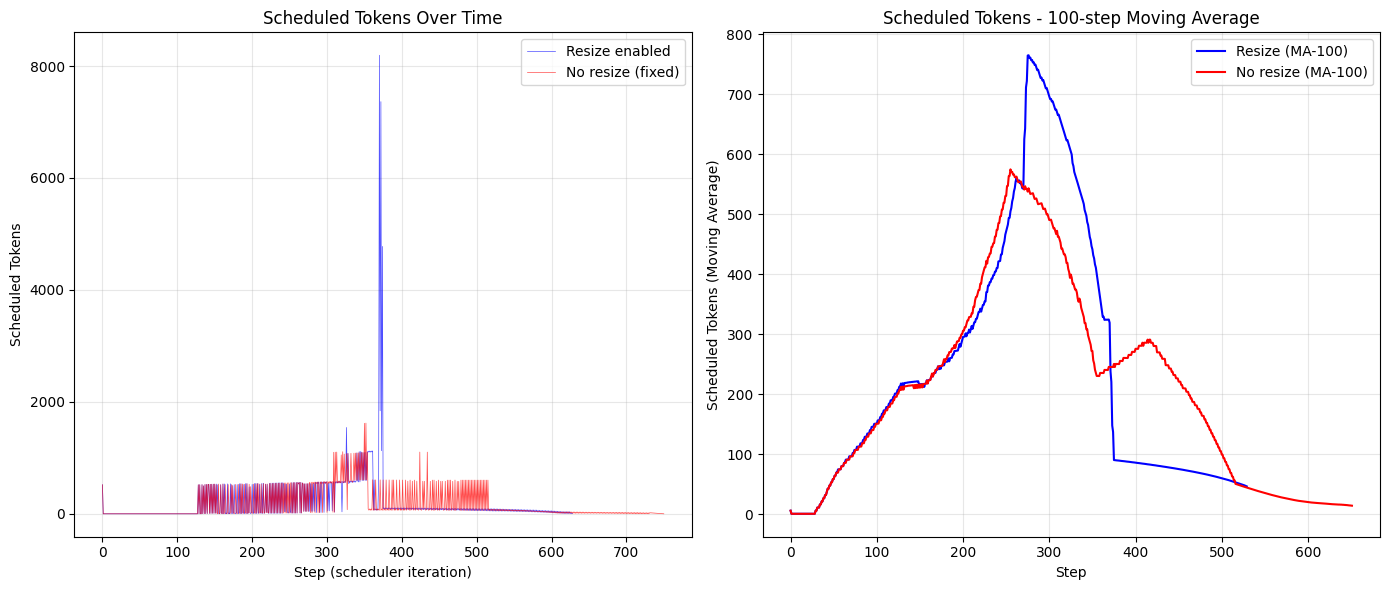

In [4]:
# Line chart comparing scheduled tokens over time
plt.figure(figsize=(14, 6))

# Plot both traces
x_resize = np.arange(len(resize_tokens))
x_no_resize = np.arange(len(no_resize_tokens))

plt.subplot(1, 2, 1)
plt.plot(x_resize, resize_tokens, 'b-', alpha=0.7, linewidth=0.5, label='Resize enabled')
plt.plot(x_no_resize, no_resize_tokens, 'r-', alpha=0.7, linewidth=0.5, label='No resize (fixed)')
plt.xlabel('Step (scheduler iteration)')
plt.ylabel('Scheduled Tokens')
plt.title('Scheduled Tokens Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

# Rolling average for clearer trend
window = 100
resize_ma = np.convolve(resize_tokens, np.ones(window)/window, mode='valid')
no_resize_ma = np.convolve(no_resize_tokens, np.ones(window)/window, mode='valid')

plt.subplot(1, 2, 2)
plt.plot(resize_ma, 'b-', linewidth=1.5, label=f'Resize (MA-{window})')
plt.plot(no_resize_ma, 'r-', linewidth=1.5, label=f'No resize (MA-{window})')
plt.xlabel('Step')
plt.ylabel('Scheduled Tokens (Moving Average)')
plt.title(f'Scheduled Tokens - {window}-step Moving Average')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# Statistics comparison
print("=" * 60)
print("Statistics Comparison: Scheduled Tokens")
print("=" * 60)

resize_arr = np.array(resize_tokens)
no_resize_arr = np.array(no_resize_tokens)

stats = {
    'Metric': ['Mean', 'Std', 'Min', 'Max', 'Median', 'Total Steps'],
    'Resize': [
        f"{np.mean(resize_arr):.2f}",
        f"{np.std(resize_arr):.2f}",
        f"{np.min(resize_arr)}",
        f"{np.max(resize_arr)}",
        f"{np.median(resize_arr):.2f}",
        f"{len(resize_arr)}"
    ],
    'No Resize': [
        f"{np.mean(no_resize_arr):.2f}",
        f"{np.std(no_resize_arr):.2f}",
        f"{np.min(no_resize_arr)}",
        f"{np.max(no_resize_arr)}",
        f"{np.median(no_resize_arr):.2f}",
        f"{len(no_resize_arr)}"
    ]
}

for i, metric in enumerate(stats['Metric']):
    print(f"{metric:15} | Resize: {stats['Resize'][i]:12} | No Resize: {stats['No Resize'][i]:12}")

Statistics Comparison: Scheduled Tokens
Mean            | Resize: 207.26       | No Resize: 180.52      
Std             | Resize: 538.86       | No Resize: 278.74      
Min             | Resize: 1            | No Resize: 1           
Max             | Resize: 8192         | No Resize: 1621        
Median          | Resize: 61.00        | No Resize: 40.00       
Total Steps     | Resize: 629          | No Resize: 751         


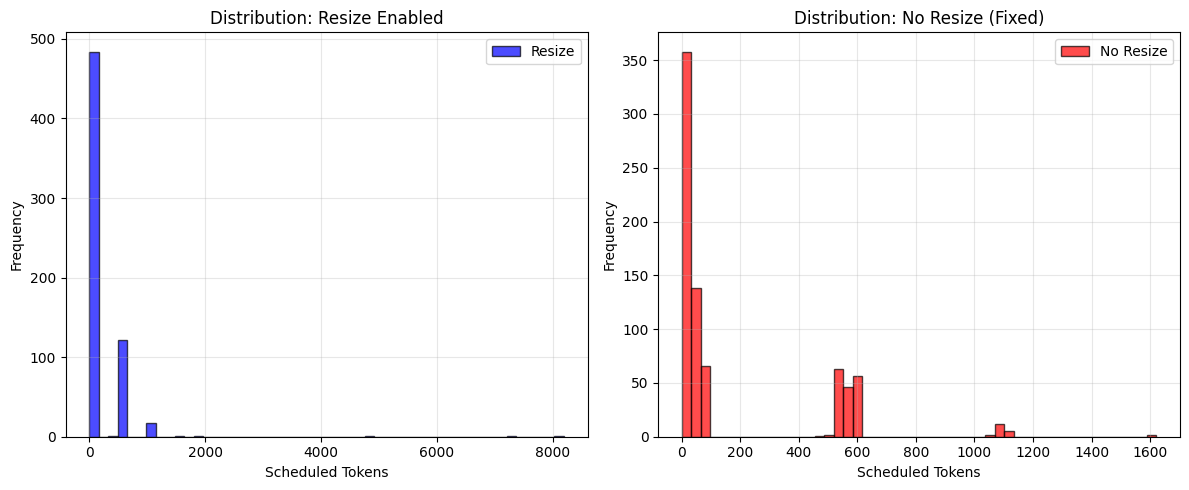

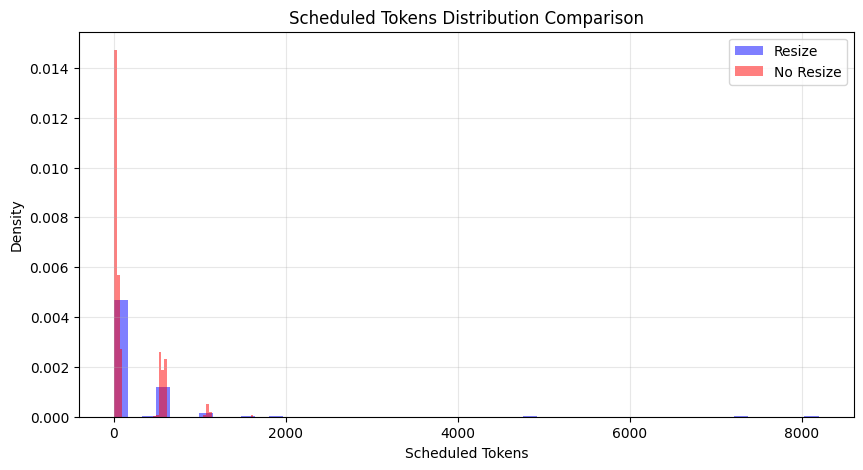

In [6]:
# Histogram comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(resize_tokens, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Resize')
plt.xlabel('Scheduled Tokens')
plt.ylabel('Frequency')
plt.title('Distribution: Resize Enabled')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(no_resize_tokens, bins=50, alpha=0.7, color='red', edgecolor='black', label='No Resize')
plt.xlabel('Scheduled Tokens')
plt.ylabel('Frequency')
plt.title('Distribution: No Resize (Fixed)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overlaid histogram
plt.figure(figsize=(10, 5))
plt.hist(resize_tokens, bins=50, alpha=0.5, color='blue', label='Resize', density=True)
plt.hist(no_resize_tokens, bins=50, alpha=0.5, color='red', label='No Resize', density=True)
plt.xlabel('Scheduled Tokens')
plt.ylabel('Density')
plt.title('Scheduled Tokens Distribution Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()